# XGBoost

Post-binning contig correctness prediction on the bundled SPAdes example data.

This notebook discovers dataset folders under `tests/data/` and reads each folder's `initial_contig_bins.csv` as the initial binner output. The target is `0` for an incorrect initial bin assignment and `1` for a correct assignment among binned contigs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
try:
    import seaborn as sns
except ImportError:
    sns = None

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "tests" / "data").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

for module_name in list(sys.modules):
    if module_name == "binfailgraph" or module_name.startswith("binfailgraph."):
        del sys.modules[module_name]

from binfailgraph.datasets import discover_datasets
from binfailgraph.features import build_feature_table
from binfailgraph.labels import make_contig_labels, task_frame
from binfailgraph.modeling import (
    COMPARISON_FEATURE_SETS,
    combined_dataset_metric_table,
    combined_task_frame,
    comparison_feature_columns,
    compare_feature_sets,
    plot_combined_dataset_roc_curves,
    plot_feature_boxplots_by_outcome,
    plot_feature_set_roc_curves,
    plot_transfer_heatmap,
    select_feature_columns,
    transfer_feature_set_table,
)

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")
DATA_ROOT = ROOT / "tests" / "data"
DATASETS = discover_datasets(DATA_ROOT)
IMAGES_DIR = ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)
INCLUDE_KMERS = True
TASK = "misbin"


def slugify(value):
    slug = "".join(char.lower() if char.isalnum() else "_" for char in str(value))
    return "_".join(part for part in slug.split("_") if part)

## Data and Labels

In [2]:
dataset_features = {}
dataset_labelled = {}
dataset_tasks = {}
dataset_summary_rows = []

for dataset in DATASETS:
    raw_features = build_feature_table(
        graph_file=dataset.graph_file,
        contigs_file=dataset.contigs_file,
        contig_paths_file=dataset.contig_paths_file,
        ground_truth_file=dataset.ground_truth_file,
        bin_assignments_file=dataset.bin_assignments_file,
        include_kmers=INCLUDE_KMERS,
    )
    labelled = make_contig_labels(raw_features)
    task = task_frame(labelled, task=TASK)

    dataset_features[dataset.name] = raw_features
    dataset_labelled[dataset.name] = labelled
    dataset_tasks[dataset.name] = task
    dataset_summary_rows.append(
        {
            "dataset": dataset.name,
            "graph_contigs": len(raw_features),
            "initial_binned_contigs": int(raw_features["bin"].notna().sum()),
            "task_rows": len(task),
            "incorrect_assignments": int((task["target"] == 0).sum()),
            "correct_assignments": int(task["target"].sum()),
        }
    )

print("Target convention: 0 = incorrect initial bin assignment, 1 = correct initial bin assignment")
display(pd.DataFrame(dataset_summary_rows))

Target convention: 0 = incorrect initial bin assignment, 1 = correct initial bin assignment


,dataset,graph_contigs,initial_binned_contigs,task_rows,incorrect_assignments,correct_assignments
0,Sim-100G,15729,5723,3976,1182,2794
1,Sim-10G,920,341,331,25,306
2,Sim-20G,1452,610,597,58,539
3,Sim-50G,5088,1923,1884,403,1481
4,Sim-5G,519,209,206,14,192


## Feature Distributions

Boxplots compare correct and failed contigs after pooling all discovered datasets. Only the curated 9-feature comparison universe is plotted; raw 4-mer columns remain collapsed into `4mer_composition_distance`. Each feature is saved as a standalone PNG under `images/`. Asterisks use two-sided Mann-Whitney U tests with Benjamini-Hochberg FDR correction.

Plotting 9 curated comparison features pooled across 5 datasets.


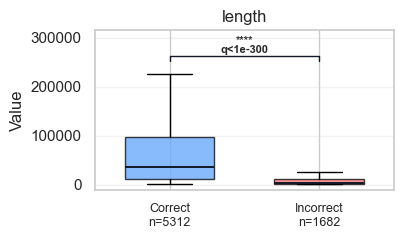

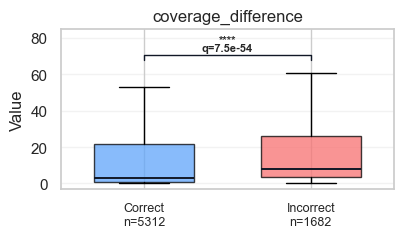

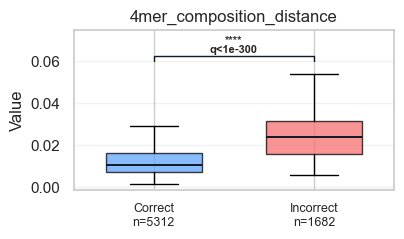

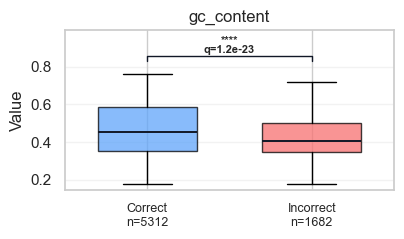

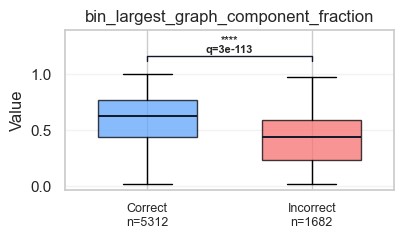

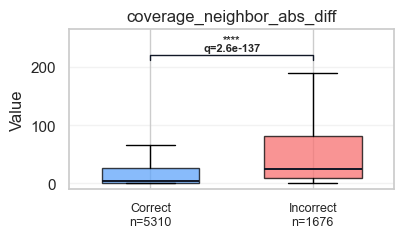

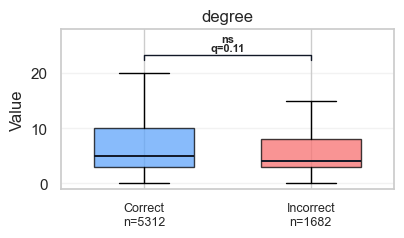

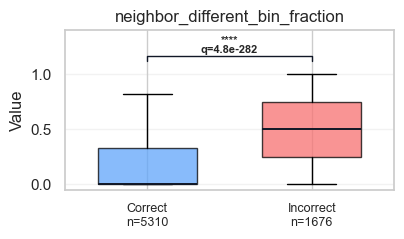

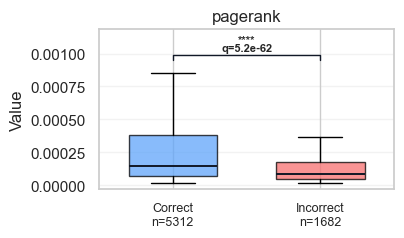

,feature,image
0,length,images/feature_distribution_length.pdf
1,coverage_difference,images/feature_distribution_coverage_differenc...
2,4mer_composition_distance,images/feature_distribution_4mer_composition_d...
3,gc_content,images/feature_distribution_gc_content.pdf
4,bin_largest_graph_component_fraction,images/feature_distribution_bin_largest_graph_...
5,coverage_neighbor_abs_diff,images/feature_distribution_coverage_neighbor_...
6,degree,images/feature_distribution_degree.pdf
7,neighbor_different_bin_fraction,images/feature_distribution_neighbor_different...
8,pagerank,images/feature_distribution_pagerank.pdf


In [3]:
pooled_task = combined_task_frame(dataset_tasks)
distribution_feature_columns = comparison_feature_columns(
    pooled_task,
    feature_sets=COMPARISON_FEATURE_SETS,
)
print(
    f"Plotting {len(distribution_feature_columns)} curated comparison features pooled across "
    f"{len(dataset_tasks)} datasets."
)
feature_distribution_rows = []

for feature_name in distribution_feature_columns:
    figures = plot_feature_boxplots_by_outcome(
        pooled_task,
        [feature_name],
        features_per_figure=1,
        ncols=1,
        showfliers=False,
        p_adjust="fdr_bh",
    )
    fig = figures[0]
    fig.set_size_inches(4.2, 2.55, forward=True)
    ax = fig.axes[0]
    ax.set_title(feature_name)
    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.remove()
    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min
    if y_span > 0:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        text_tops = []
        for text in ax.texts:
            bbox = text.get_window_extent(renderer=renderer)
            text_top = ax.transData.inverted().transform((bbox.x0, bbox.y1))[1]
            if text_top > y_min:
                text_tops.append(text_top)
        if text_tops:
            ax.set_ylim(y_min, max(y_max, max(text_tops) + 0.04 * y_span))
    fig.tight_layout()
    image_path = IMAGES_DIR / f"feature_distribution_{slugify(feature_name)}.pdf"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    feature_distribution_rows.append(
        {
            "feature": feature_name,
            "image": str(image_path.relative_to(ROOT)),
        }
    )
    plt.show()

display(pd.DataFrame(feature_distribution_rows))

## Model

In [4]:
from binfailgraph.modeling import make_xgboost

MODEL_NAME = "XGBoost"
def MODEL_FACTORY(current_task):
    return make_xgboost(y_train=current_task["target"], random_state=42)

## Feature-Set Comparison

The same model is evaluated with six feature sets: length only, coverage-difference only, composition only, composition + coverage difference, graph only, and the curated 9-feature composition + coverage difference + graph set. Performance is reported with AUROC and AUPRC.

In [5]:
comparison_tables = []
comparison_results_by_dataset = {}

print("Feature sets evaluated:", ", ".join(COMPARISON_FEATURE_SETS))

for dataset_name, current_task in dataset_tasks.items():
    table, results = compare_feature_sets(
        current_task,
        model_factory=lambda current_task=current_task: MODEL_FACTORY(current_task),
        feature_sets=COMPARISON_FEATURE_SETS,
        target_col="target",
        test_size=0.30,
        random_state=42,
        top_k_fraction=0.10,
    )
    table.insert(0, "dataset", dataset_name)
    comparison_tables.append(table)
    comparison_results_by_dataset[dataset_name] = results

comparison_table = pd.concat(comparison_tables, ignore_index=True)
display(
    comparison_table[
        ["dataset", "feature_set_label", "n_features", "auroc", "auprc", "f1", "precision", "recall"]
    ].style.format({"auroc": "{:.3f}", "auprc": "{:.3f}", "f1": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}"})
)

primary_dataset = sorted(dataset_tasks)[0]
primary_task = dataset_tasks[primary_dataset]
result = comparison_results_by_dataset[primary_dataset]["composition_coverage_graph"]
feature_columns = select_feature_columns(primary_task, feature_set="composition_coverage_graph")
print(
    f"Using {primary_dataset!r} and {len(feature_columns):,} curated composition + coverage difference + graph features "
    "for diagnostics below."
)
display(result.metrics.to_frame("value"))
display(result.test_predictions.head(25))

Feature sets evaluated: length_only, coverage_only, composition_only, composition_coverage, graph_only, composition_coverage_graph


,dataset,feature_set_label,n_features,auroc,auprc,f1,precision,recall
0,Sim-100G,Length only,1,0.824,0.908,0.781,0.885,0.699
1,Sim-100G,Coverage difference only,1,0.705,0.847,0.710,0.827,0.622
2,Sim-100G,Composition difference only,2,0.859,0.937,0.804,0.900,0.727
3,Sim-100G,Composition + coverage,3,0.885,0.949,0.826,0.908,0.758
4,Sim-100G,Graph only,5,0.902,0.956,0.859,0.922,0.804
5,Sim-100G,Composition + coverage + graph,9,0.955,0.980,0.910,0.953,0.870
6,Sim-10G,Length only,1,0.908,0.991,0.905,1.000,0.826
7,Sim-10G,Coverage difference only,1,0.756,0.961,0.962,0.967,0.957
8,Sim-10G,Composition difference only,2,0.921,0.993,0.898,1.000,0.815
9,Sim-10G,Composition + coverage,3,0.955,0.996,0.912,0.987,0.848


Using 'Sim-100G' and 9 curated composition + coverage difference + graph features for diagnostics below.


,value
n_train,2783.000000
n_test,1193.000000
correct_rate_test,0.702431
f1,0.909545
precision,0.952941
recall,0.869928
ece_10bin,0.068470
auroc,0.954523
auprc,0.980251
precision_at_top_10pct,1.000000


,bin,contig,contig_short,target,correctness_score
137,79.0,NODE_138_length_345170_cov_21.622390,NODE_138,1,0.999735
135,79.0,NODE_136_length_347186_cov_20.728111,NODE_136,1,0.999711
171,89.0,NODE_172_length_302855_cov_15.874128,NODE_172,1,0.999676
183,79.0,NODE_184_length_287424_cov_22.237941,NODE_184,1,0.999672
442,81.0,NODE_443_length_163422_cov_19.741270,NODE_443,1,0.999663
303,61.0,NODE_304_length_209602_cov_35.295075,NODE_304,1,0.999603
117,52.0,NODE_118_length_385008_cov_41.517920,NODE_118,1,0.999582
1266,61.0,NODE_1267_length_63565_cov_35.061833,NODE_1267,1,0.999569
103,60.0,NODE_104_length_399358_cov_35.657265,NODE_104,1,0.999539
1940,81.0,NODE_1941_length_36593_cov_19.256309,NODE_1941,1,0.999482


## ROC Curves

Each dataset ROC curve is drawn as a standalone figure and saved under `images/`.

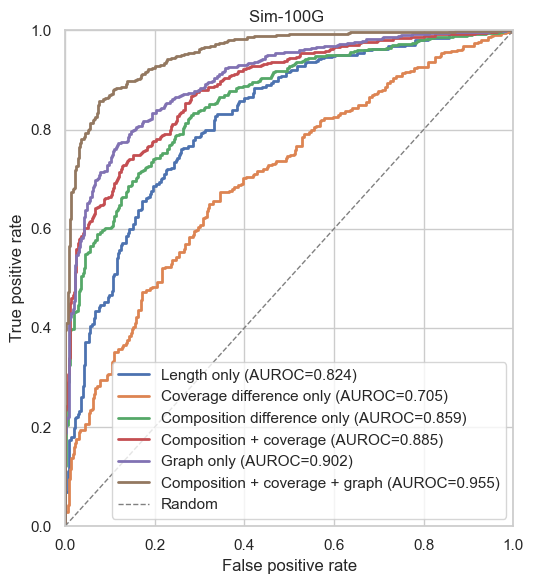

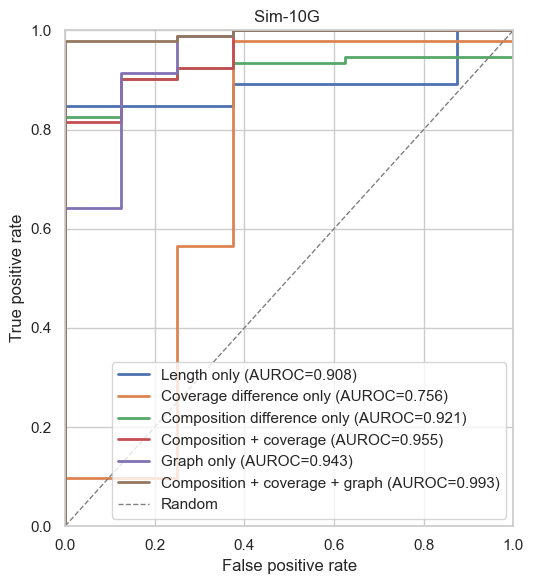

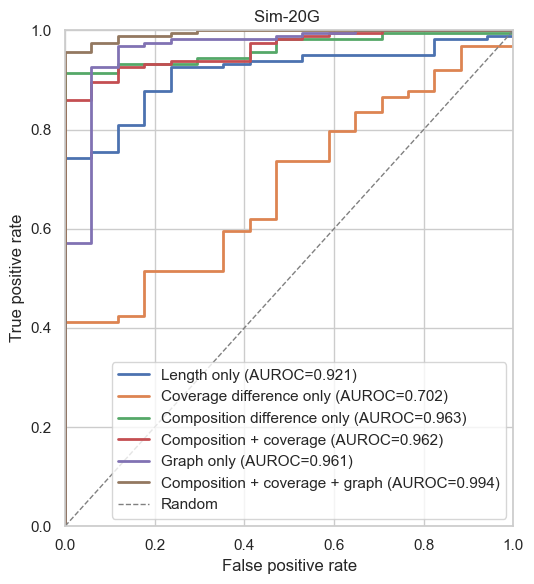

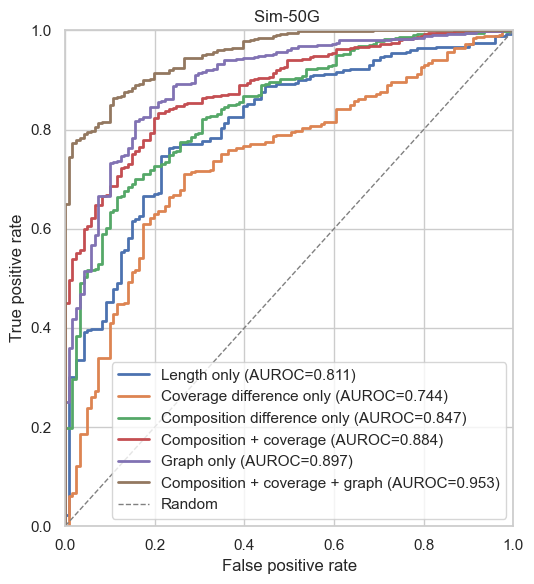

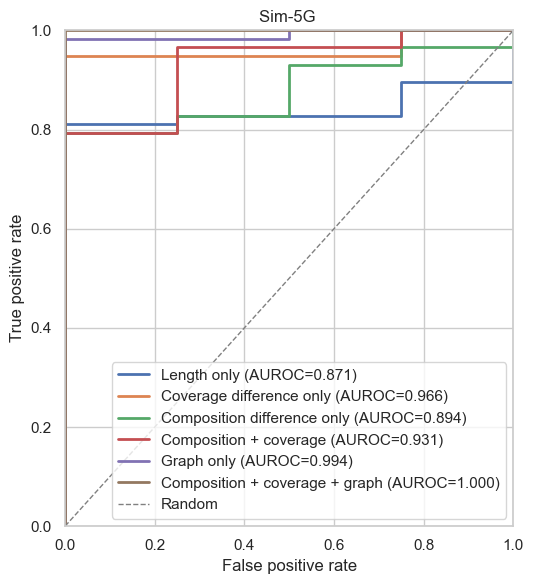

,dataset,model,image
0,Sim-100G,XGBoost,images/xgboost_sim_100g_roc.pdf
1,Sim-10G,XGBoost,images/xgboost_sim_10g_roc.pdf
2,Sim-20G,XGBoost,images/xgboost_sim_20g_roc.pdf
3,Sim-50G,XGBoost,images/xgboost_sim_50g_roc.pdf
4,Sim-5G,XGBoost,images/xgboost_sim_5g_roc.pdf


In [6]:
roc_image_rows = []

for dataset_name, results in comparison_results_by_dataset.items():
    fig, ax = plt.subplots(figsize=(5.5, 6))
    plot_feature_set_roc_curves(results, ax=ax)
    ax.set_title(f"{dataset_name} ")
    plt.tight_layout()

    image_path = IMAGES_DIR / f"{slugify(MODEL_NAME)}_{slugify(dataset_name)}_roc.pdf"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    roc_image_rows.append(
        {
            "dataset": dataset_name,
            "model": MODEL_NAME,
            "image": str(image_path.relative_to(ROOT)),
        }
    )
    plt.show()

display(pd.DataFrame(roc_image_rows))

## Combined ROC Curves Across Datasets

These curves pool the held-out predictions from each dataset-specific run for the same feature set. The combined ROC figure is saved under `images/`.

,feature_set_label,n_test,correct_rate,auroc,auprc,f1,precision,recall
0,Length only,2101,0.760,0.834,0.938,0.802,0.918,0.712
1,Coverage difference only,2101,0.760,0.739,0.896,0.762,0.877,0.673
2,Composition difference only,2101,0.760,0.870,0.955,0.834,0.924,0.760
3,Composition + coverage,2101,0.760,0.897,0.966,0.856,0.933,0.791
4,Graph only,2101,0.760,0.912,0.969,0.883,0.942,0.831
5,Composition + coverage + graph,2101,0.760,0.961,0.987,0.925,0.963,0.890


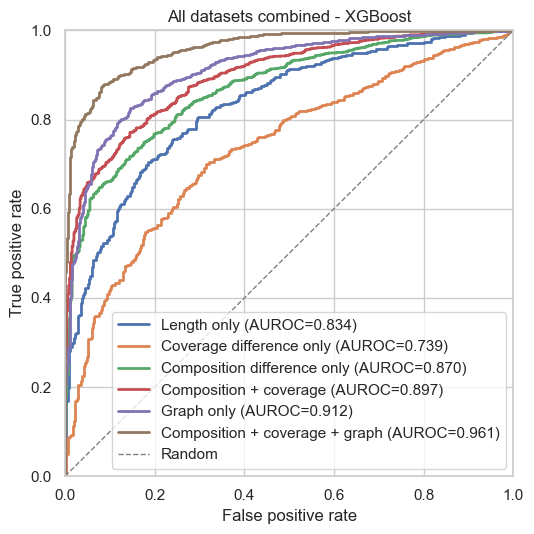

,dataset,model,image
0,combined,XGBoost,images/xgboost_combined_datasets_roc.pdf


In [7]:
combined_table = combined_dataset_metric_table(
    comparison_results_by_dataset,
    feature_sets=COMPARISON_FEATURE_SETS,
)
display(
    combined_table[
        ["feature_set_label", "n_test", "correct_rate", "auroc", "auprc", "f1", "precision", "recall"]
    ].style.format({"correct_rate": "{:.3f}", "auroc": "{:.3f}", "auprc": "{:.3f}", "f1": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}"})
)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
plot_combined_dataset_roc_curves(
    comparison_results_by_dataset,
    feature_sets=COMPARISON_FEATURE_SETS,
    ax=ax,
)
ax.set_title("All datasets combined - XGBoost")
plt.tight_layout()
combined_roc_image = IMAGES_DIR / f"{slugify(MODEL_NAME)}_combined_datasets_roc.pdf"
fig.savefig(combined_roc_image, dpi=300, bbox_inches="tight")
plt.show()
display(
    pd.DataFrame(
        [
            {
                "dataset": "combined",
                "model": MODEL_NAME,
                "image": str(combined_roc_image.relative_to(ROOT)),
            }
        ]
    )
)

## Dataset Transfer Heatmaps

This section evaluates strict dataset-level transfer for the curated `composition_coverage_graph` model. Columns are test datasets, while rows are non-empty training-dataset combinations from `tests/data/`. A cell is evaluated only when the test dataset is not part of the training combination; cells that would train and test on the same dataset are intentionally left blank. The second heatmap reports failure-class AUPRC, using `1 - correctness_score` as the predicted failure risk.

,train_dataset,train_dataset_count,test_dataset,evaluation_mode,n_features,n_train,n_test,failure_rate_test,auroc,failure_auprc
0,Sim-100G,1,Sim-10G,cross_dataset_transfer,9,3976,331,0.076,0.985,0.884
1,Sim-100G,1,Sim-20G,cross_dataset_transfer,9,3976,597,0.097,0.987,0.896
2,Sim-100G,1,Sim-50G,cross_dataset_transfer,9,3976,1884,0.214,0.884,0.714
3,Sim-100G,1,Sim-5G,cross_dataset_transfer,9,3976,206,0.068,0.978,0.855
4,Sim-10G,1,Sim-100G,cross_dataset_transfer,9,331,3976,0.297,0.813,0.694
5,Sim-10G,1,Sim-20G,cross_dataset_transfer,9,331,597,0.097,0.960,0.832
6,Sim-10G,1,Sim-50G,cross_dataset_transfer,9,331,1884,0.214,0.825,0.629
7,Sim-10G,1,Sim-5G,cross_dataset_transfer,9,331,206,0.068,0.977,0.781
8,Sim-20G,1,Sim-100G,cross_dataset_transfer,9,597,3976,0.297,0.865,0.764
9,Sim-20G,1,Sim-10G,cross_dataset_transfer,9,597,331,0.076,0.988,0.915


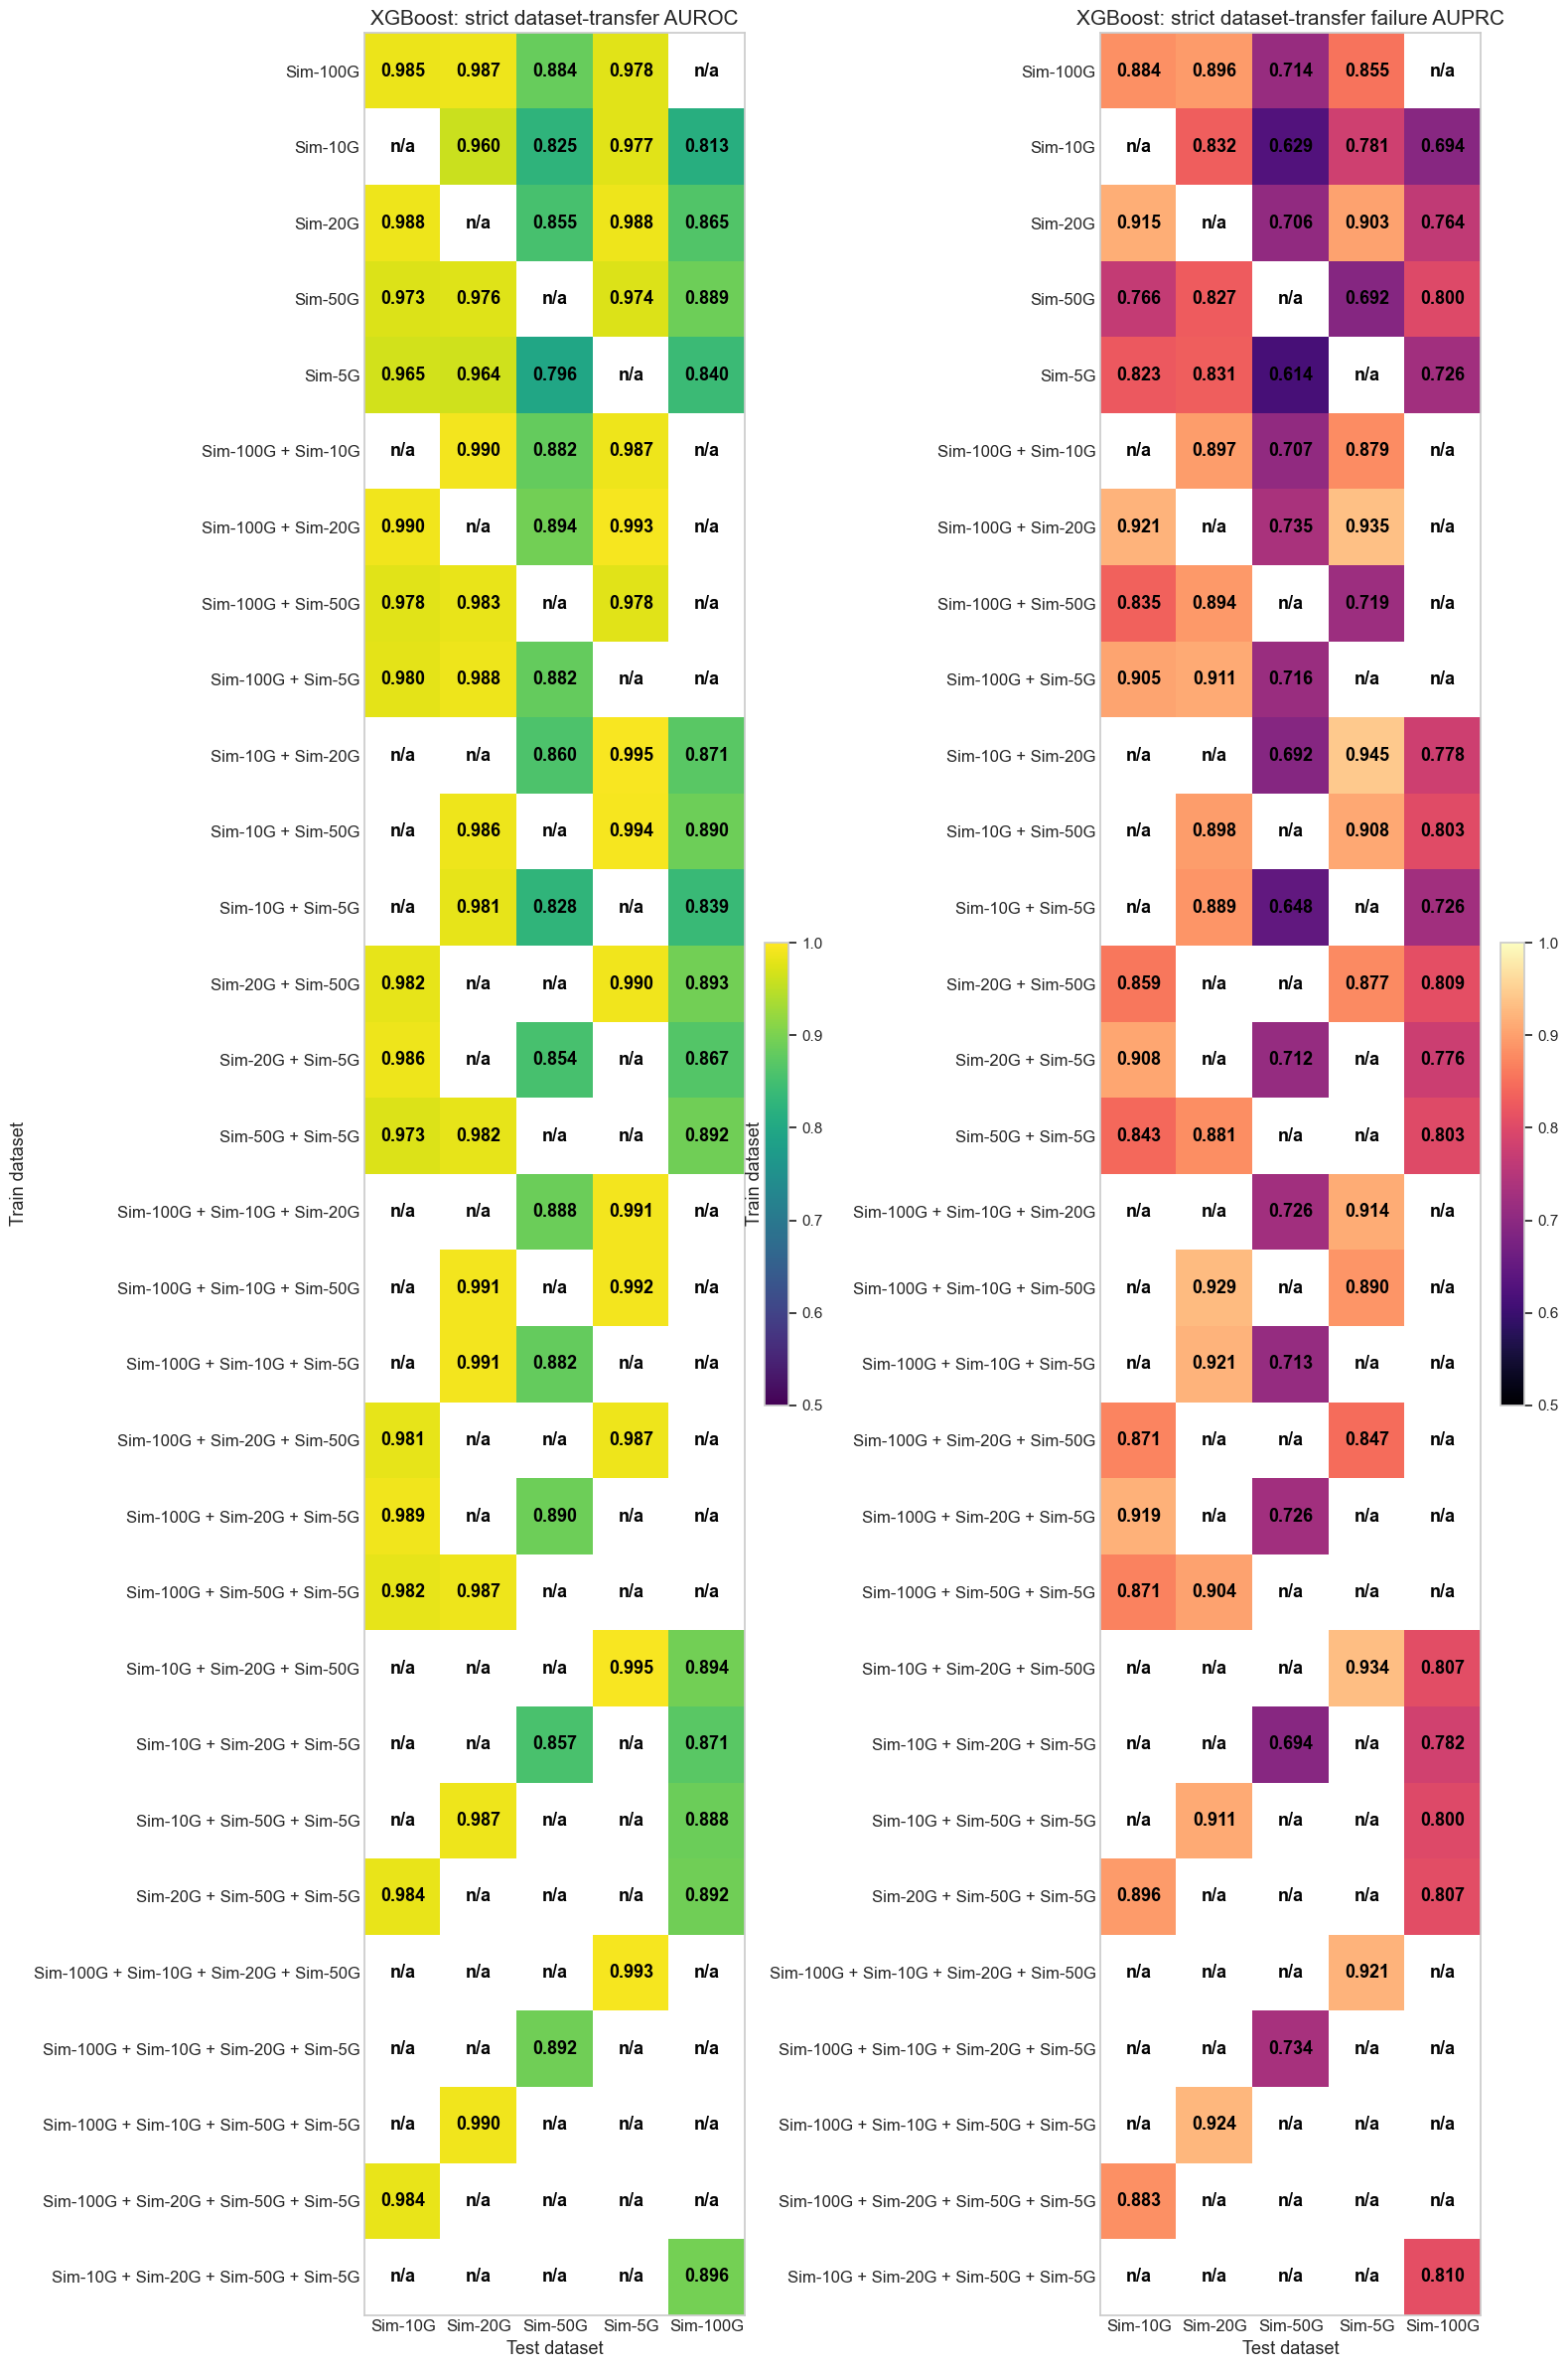

In [8]:
TRANSFER_FEATURE_SET = "composition_coverage_graph"

transfer_metrics_table = transfer_feature_set_table(
    dataset_tasks,
    model_factory=lambda train_task: MODEL_FACTORY(train_task),
    feature_set=TRANSFER_FEATURE_SET,
    target_col="target",
    test_size=0.30,
    random_state=42,
    max_train_combination_size=None,
    allow_train_test_overlap=False,
)

if transfer_metrics_table.empty:
    print("Strict dataset-level transfer requires at least two labelled datasets.")
else:
    display(
        transfer_metrics_table[
            [
                "train_dataset",
                "train_dataset_count",
                "test_dataset",
                "evaluation_mode",
                "n_features",
                "n_train",
                "n_test",
                "failure_rate_test",
                "auroc",
                "failure_auprc",
            ]
        ].style.format(
            {
                "failure_rate_test": "{:.3f}",
                "auroc": "{:.3f}",
                "failure_auprc": "{:.3f}",
            }
        )
    )

    n_train_rows = transfer_metrics_table["train_dataset"].nunique()
    heatmap_height = max(5, 0.75 * n_train_rows + 1.5)
    fig, axes = plt.subplots(1, 2, figsize=(15, heatmap_height))
    plot_transfer_heatmap(
        transfer_metrics_table,
        metric="auroc",
        ax=axes[0],
        title=f"{MODEL_NAME}: strict dataset-transfer AUROC",
        vmin=0.5,
        vmax=1.0,
        cmap="viridis",
    )
    plot_transfer_heatmap(
        transfer_metrics_table,
        metric="failure_auprc",
        ax=axes[1],
        title=f"{MODEL_NAME}: strict dataset-transfer failure AUPRC",
        vmin=0.5,
        vmax=1.0,
        cmap="magma",
    )
    plt.tight_layout()
    plt.show()

## External Test Dataset

This section trains the current model on all datasets in `tests/data/` using the curated `composition_coverage_graph` feature set, then tests it on every dataset discovered under `tests/test_data/`, such as `Sim-20G`. It reports AUROC, AUPRC, threshold-based classification metrics, calibration error, top-10% precision/recall, a confusion matrix, and an external-test ROC curve.

External test: trained XGBoost on 6,994 rows from tests/data and tested on 13 dataset(s) from tests/test_data.
Feature set: composition_coverage_graph (9 features)


,dataset,graph_contigs,initial_binned_contigs,test_rows,incorrect_assignments,correct_assignments
0,Deep_HMP-concoct,115108,12230,583,69,514
1,Deep_HMP-maxbin,115108,12033,575,88,487
2,Deep_HMP-metabat2,115108,813,100,2,98
3,Deep_HMP-vamb,115108,1552,207,88,119
4,Sharon-concoct,42313,4409,940,279,661
5,Sharon-maxbin,42313,4402,938,163,775
6,Sharon-metabat2,42313,496,212,56,156
7,Sharon-vamb,42313,453,236,163,73
8,Sim-100G,15729,6703,4848,1783,3065
9,Sim-10G,920,394,383,47,336


,dataset,model,n_train,n_test,correct_rate_test,auroc,auprc,accuracy,f1,precision,recall,ece_10bin,precision_at_top_10pct,recall_at_top_10pct
0,Deep_HMP-concoct,XGBoost,6994,583,0.882,0.631,0.934,0.571,0.697,0.923,0.560,0.361,1.000,0.115
1,Deep_HMP-maxbin,XGBoost,6994,575,0.847,0.578,0.901,0.555,0.682,0.862,0.565,0.329,1.000,0.119
2,Deep_HMP-metabat2,XGBoost,6994,100,0.980,0.342,0.979,0.450,0.621,0.957,0.459,0.473,1.000,0.102
3,Deep_HMP-vamb,XGBoost,6994,207,0.575,0.509,0.644,0.536,0.628,0.583,0.681,0.175,0.857,0.151
4,Sharon-concoct,XGBoost,6994,940,0.703,0.355,0.628,0.489,0.615,0.655,0.579,0.371,0.521,0.074
5,Sharon-maxbin,XGBoost,6994,938,0.826,0.759,0.931,0.659,0.761,0.903,0.658,0.315,1.000,0.121
6,Sharon-metabat2,XGBoost,6994,212,0.736,0.524,0.812,0.646,0.776,0.726,0.833,0.202,1.000,0.141
7,Sharon-vamb,XGBoost,6994,236,0.309,0.622,0.390,0.347,0.473,0.315,0.945,0.478,0.333,0.110
8,Sim-100G,XGBoost,6994,4848,0.632,0.816,0.868,0.780,0.838,0.784,0.900,0.097,0.940,0.149
9,Sim-10G,XGBoost,6994,383,0.877,0.935,0.990,0.916,0.953,0.939,0.967,0.055,1.000,0.116


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),45,24
True correct (1),226,288


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),44,44
True correct (1),212,275


...

,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),1023,760
True correct (1),305,2760


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),26,21
True correct (1),11,325


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),63,34
True correct (1),30,537


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),332,469
True correct (1),162,1229


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),15,4
True correct (1),31,198


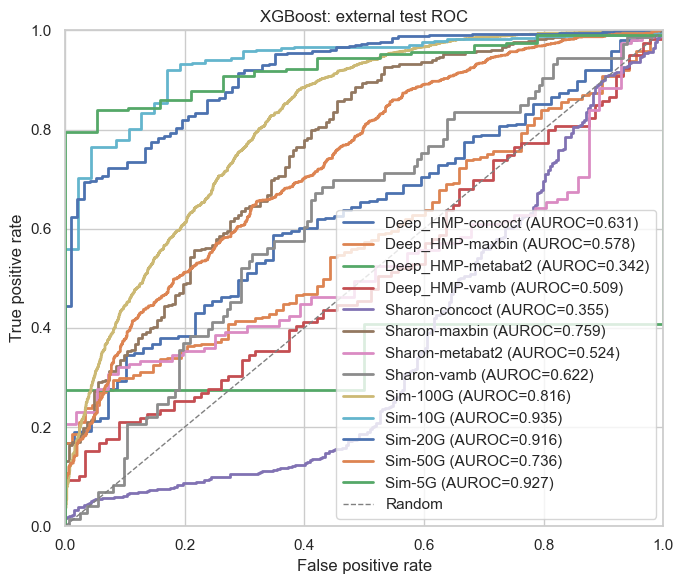

,dataset,model,image
0,external_test,XGBoost,images/xgboost_external_test_roc.pdf


In [9]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from binfailgraph.modeling import expected_calibration_error, precision_recall_at_top_k

EXTERNAL_DATA_ROOT = ROOT / "tests" / "test_data"
WINNING_FEATURE_SET = "composition_coverage_graph"

if not EXTERNAL_DATA_ROOT.exists():
    print(f"No external test-data directory found at {EXTERNAL_DATA_ROOT}")
else:
    external_datasets = discover_datasets(EXTERNAL_DATA_ROOT)
    external_features = {}
    external_tasks = {}
    external_summary_rows = []

    for dataset in external_datasets:
        raw_features = build_feature_table(
            graph_file=dataset.graph_file,
            contigs_file=dataset.contigs_file,
            contig_paths_file=dataset.contig_paths_file,
            ground_truth_file=dataset.ground_truth_file,
            bin_assignments_file=dataset.bin_assignments_file,
            include_kmers=INCLUDE_KMERS,
        )
        labelled = make_contig_labels(raw_features)
        task = task_frame(labelled, task=TASK)

        external_features[dataset.name] = raw_features
        external_tasks[dataset.name] = task
        external_summary_rows.append(
            {
                "dataset": dataset.name,
                "graph_contigs": len(raw_features),
                "initial_binned_contigs": int(raw_features["bin"].notna().sum()),
                "test_rows": len(task),
                "incorrect_assignments": int((task["target"] == 0).sum()),
                "correct_assignments": int(task["target"].sum()),
            }
        )

    train_task = pd.concat(
        [task.assign(dataset=dataset_name) for dataset_name, task in dataset_tasks.items()],
        ignore_index=True,
    )
    external_feature_columns = select_feature_columns(
        train_task,
        feature_set=WINNING_FEATURE_SET,
        target_col="target",
    )
    x_train = train_task[external_feature_columns]
    y_train = train_task["target"].astype(int)

    external_model = MODEL_FACTORY(train_task)
    external_model.fit(x_train, y_train)

    external_metric_rows = []
    external_confusion_matrices = {}
    external_roc_curves = []

    for dataset_name, test_task in external_tasks.items():
        missing_columns = [
            column for column in external_feature_columns if column not in test_task.columns
        ]
        if missing_columns:
            raise ValueError(
                f"{dataset_name} is missing external-test feature columns: {missing_columns}"
            )

        x_test = test_task[external_feature_columns]
        y_test = test_task["target"].astype(int)
        y_score = external_model.predict_proba(x_test)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)
        precision_top, recall_top = precision_recall_at_top_k(y_test, y_score, 0.10)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        external_metric_rows.append(
            {
                "dataset": dataset_name,
                "model": MODEL_NAME,
                "feature_set": WINNING_FEATURE_SET,
                "n_train": len(y_train),
                "n_test": len(y_test),
                "correct_rate_test": float(y_test.mean()),
                "auroc": roc_auc_score(y_test, y_score),
                "auprc": average_precision_score(y_test, y_score),
                "accuracy": accuracy_score(y_test, y_pred),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "ece_10bin": expected_calibration_error(y_test, y_score, n_bins=10),
                "precision_at_top_10pct": precision_top,
                "recall_at_top_10pct": recall_top,
            }
        )
        external_confusion_matrices[dataset_name] = pd.DataFrame(
            [[int(tn), int(fp)], [int(fn), int(tp)]],
            index=["True incorrect (0)", "True correct (1)"],
            columns=["Predicted incorrect (0)", "Predicted correct (1)"],
        )

        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        external_roc_curves.append(
            {
                "dataset": dataset_name,
                "fpr": fpr,
                "tpr": tpr,
                "thresholds": thresholds,
                "auroc": roc_auc_score(y_test, y_score),
            }
        )

    external_summary_table = pd.DataFrame(external_summary_rows)
    external_metrics_table = pd.DataFrame(external_metric_rows)

    print(
        f"External test: trained {MODEL_NAME} on {len(y_train):,} rows from tests/data "
        f"and tested on {len(external_tasks):,} dataset(s) from tests/test_data."
    )
    print(f"Feature set: {WINNING_FEATURE_SET} ({len(external_feature_columns)} features)")
    display(external_summary_table)
    display(
        external_metrics_table[
            [
                "dataset",
                "model",
                "n_train",
                "n_test",
                "correct_rate_test",
                "auroc",
                "auprc",
                "accuracy",
                "f1",
                "precision",
                "recall",
                "ece_10bin",
                "precision_at_top_10pct",
                "recall_at_top_10pct",
            ]
        ].style.format(
            {
                "correct_rate_test": "{:.3f}",
                "auroc": "{:.3f}",
                "auprc": "{:.3f}",
                "accuracy": "{:.3f}",
                "f1": "{:.3f}",
                "precision": "{:.3f}",
                "recall": "{:.3f}",
                "ece_10bin": "{:.3f}",
                "precision_at_top_10pct": "{:.3f}",
                "recall_at_top_10pct": "{:.3f}",
            }
        )
    )
    for dataset_name, confusion_matrix_table in external_confusion_matrices.items():
        display(
            confusion_matrix_table.style.set_caption(
                f"{dataset_name}: {MODEL_NAME} confusion matrix"
            )
        )

    fig, ax = plt.subplots(figsize=(7, 6))
    for curve in external_roc_curves:
        ax.step(
            curve["fpr"],
            curve["tpr"],
            where="post",
            linewidth=2,
            label=f"{curve['dataset']} (AUROC={curve['auroc']:.3f})",
        )
    ax.plot([0, 1], [0, 1], linestyle="--", color="0.5", linewidth=1, label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{MODEL_NAME}: external test ROC")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    plt.tight_layout()
    external_roc_image = IMAGES_DIR / f"{slugify(MODEL_NAME)}_external_test_roc.pdf"
    fig.savefig(external_roc_image, dpi=300, bbox_inches="tight")
    plt.show()
    display(
        pd.DataFrame(
            [
                {
                    "dataset": "external_test",
                    "model": MODEL_NAME,
                    "image": str(external_roc_image.relative_to(ROOT)),
                }
            ]
        )
    )

## Full Feature-Set Importance

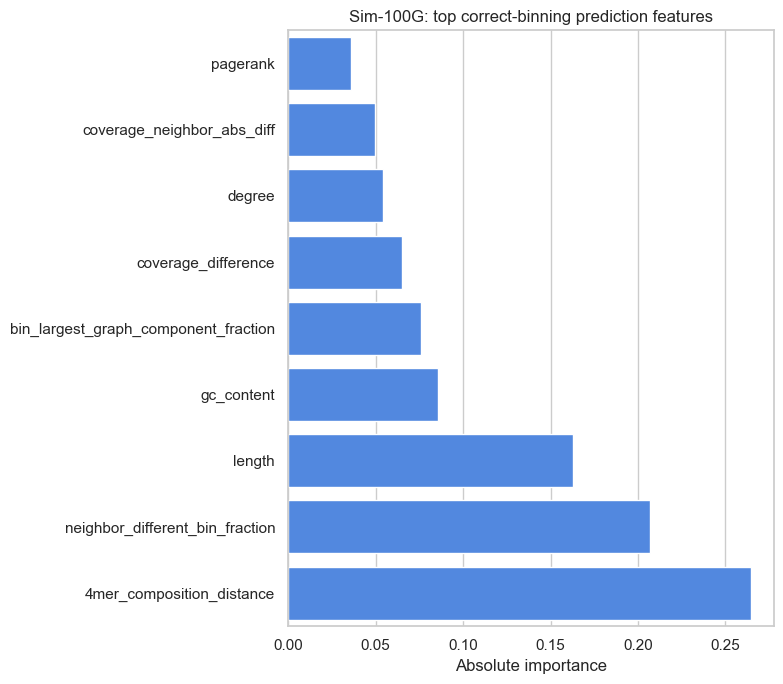

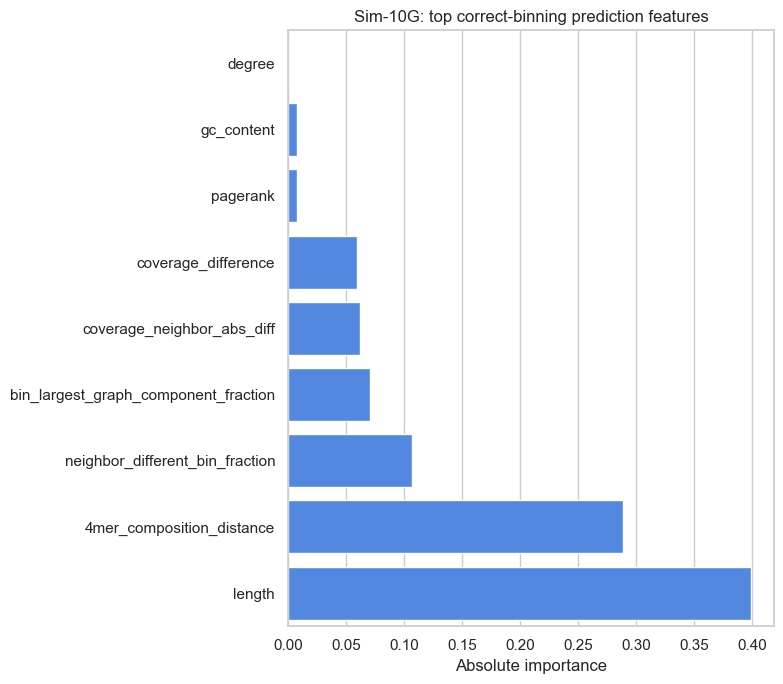

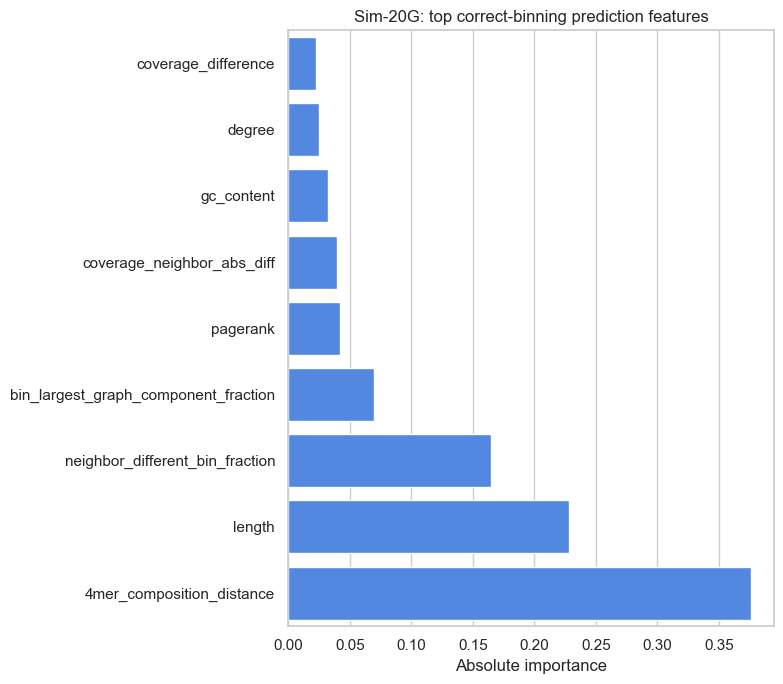

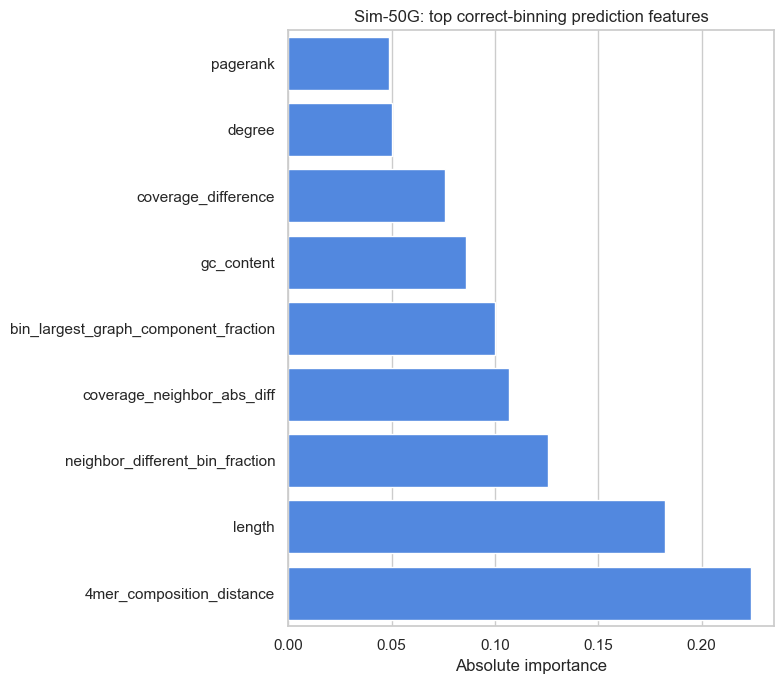

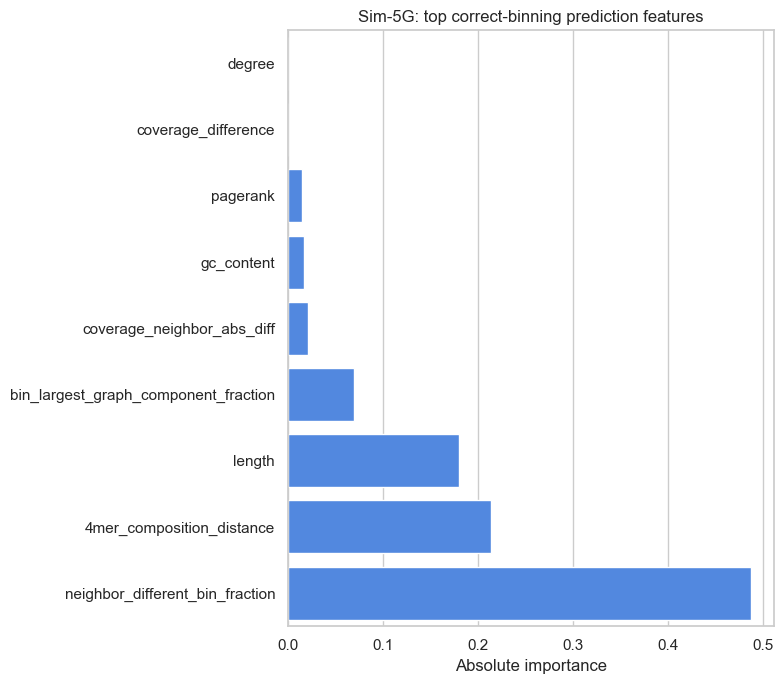

In [10]:
for dataset_name, results in comparison_results_by_dataset.items():
    top = results["composition_coverage_graph"].feature_importance.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    if sns is not None:
        sns.barplot(data=top, x="abs_importance", y="feature", ax=ax, color="#3b82f6")
    else:
        ax.barh(top["feature"], top["abs_importance"], color="#3b82f6")
    ax.set_xlabel("Absolute importance")
    ax.set_ylabel("")
    ax.set_title(f"{dataset_name}: top correct-binning prediction features")
    plt.tight_layout()
    plt.show()

## Pooled Training SHAP Summary

SHAP summaries for the model trained on the pooled training set from all datasets discovered under `tests/data/`, using the curated `composition_coverage_graph` feature set. The beeswarm and mean absolute SHAP bar plots are saved under `images/`.


/Users/vijinimallawaarachchi/miniforge3/envs/binfailgraph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


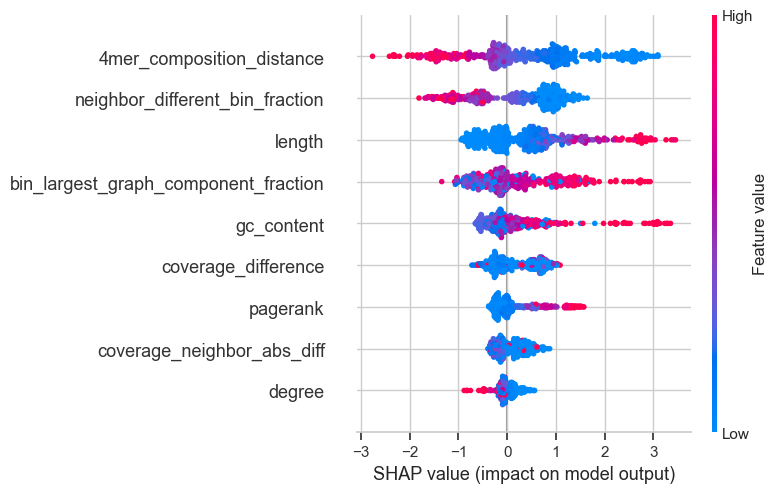

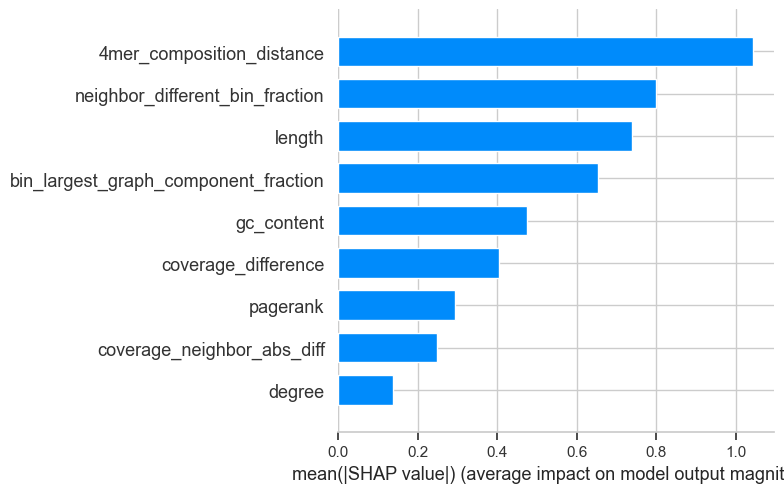

,training_set,model,feature_set,training_rows,explained_rows,plot,image
0,pooled tests/data,XGBoost,composition_coverage_graph,6994,500,beeswarm,images/xgboost_pooled_training_shap_beeswarm.pdf
1,pooled tests/data,XGBoost,composition_coverage_graph,6994,500,bar,images/xgboost_pooled_training_shap_bar.pdf


In [11]:
try:
    import shap

    POOLED_SHAP_FEATURE_SET = "composition_coverage_graph"
    SHAP_MAX_ROWS = 500

    pooled_shap_task = pd.concat(
        [task.assign(dataset=dataset_name) for dataset_name, task in dataset_tasks.items()],
        ignore_index=True,
    )
    pooled_shap_feature_columns = select_feature_columns(
        pooled_shap_task,
        feature_set=POOLED_SHAP_FEATURE_SET,
        target_col="target",
    )
    pooled_shap_x = pooled_shap_task[pooled_shap_feature_columns]
    pooled_shap_y = pooled_shap_task["target"].astype(int)

    pooled_shap_model = MODEL_FACTORY(pooled_shap_task)
    pooled_shap_model.fit(pooled_shap_x, pooled_shap_y)

    if len(pooled_shap_x) > SHAP_MAX_ROWS:
        pooled_shap_sample = pooled_shap_x.sample(n=SHAP_MAX_ROWS, random_state=42)
    else:
        pooled_shap_sample = pooled_shap_x.copy()

    transformed = pooled_shap_model.named_steps["impute"].transform(pooled_shap_sample)
    if "scale" in pooled_shap_model.named_steps:
        transformed = pooled_shap_model.named_steps["scale"].transform(transformed)
        masker = shap.maskers.Independent(
            transformed,
            max_samples=min(100, transformed.shape[0]),
        )
        explainer = shap.LinearExplainer(
            pooled_shap_model.named_steps["model"],
            masker=masker,
        )
        shap_values = explainer(transformed).values
    else:
        explainer = shap.TreeExplainer(pooled_shap_model.named_steps["model"])
        shap_values = explainer.shap_values(transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif getattr(shap_values, "ndim", 0) == 3:
            shap_values = shap_values[:, :, 1]

    shap_beeswarm_image = IMAGES_DIR / f"{slugify(MODEL_NAME)}_pooled_training_shap_beeswarm.pdf"
    shap.summary_plot(
        shap_values,
        transformed,
        feature_names=pooled_shap_feature_columns,
        max_display=20,
        show=False,
    )
    plt.gcf().savefig(shap_beeswarm_image, dpi=300, bbox_inches="tight")
    plt.show()

    shap_bar_image = IMAGES_DIR / f"{slugify(MODEL_NAME)}_pooled_training_shap_bar.pdf"
    shap.summary_plot(
        shap_values,
        transformed,
        feature_names=pooled_shap_feature_columns,
        plot_type="bar",
        max_display=20,
        show=False,
    )
    plt.gcf().savefig(shap_bar_image, dpi=300, bbox_inches="tight")
    plt.show()

    display(
        pd.DataFrame(
            [
                {
                    "training_set": "pooled tests/data",
                    "model": MODEL_NAME,
                    "feature_set": POOLED_SHAP_FEATURE_SET,
                    "training_rows": len(pooled_shap_task),
                    "explained_rows": len(pooled_shap_sample),
                    "plot": "beeswarm",
                    "image": str(shap_beeswarm_image.relative_to(ROOT)),
                },
                {
                    "training_set": "pooled tests/data",
                    "model": MODEL_NAME,
                    "feature_set": POOLED_SHAP_FEATURE_SET,
                    "training_rows": len(pooled_shap_task),
                    "explained_rows": len(pooled_shap_sample),
                    "plot": "bar",
                    "image": str(shap_bar_image.relative_to(ROOT)),
                },
            ]
        )
    )
except ImportError:
    print("Install shap from environment.yml or pyproject.toml to run this cell.")
